# 5장 2강: 부스팅 계열 모델의 원리와 발전

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 부스팅 계열 모델의 순차 학습 원리와 주요 모델의 차이를 확인합니다.

- AdaBoost와 Gradient Boosting의 순차 학습 원리를 이해합니다.
- Gradient Boosting이 이전 모델의 잔차를 보완하는 흐름을 확인합니다.
- XGBoost와 LightGBM을 같은 데이터에서 비교합니다.
- `learning_rate`, `n_estimators`, `max_depth`의 역할을 확인합니다.
- Early Stopping의 목적을 이해합니다.
- 부스팅이 단계적으로 편향을 줄여가는 이유를 설명합니다.

> 이 실습에서는 5장 2강 교안에서 다룬 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- scikit-learn
- xgboost
- lightgbm
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택의 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

### 사용할 특성

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `YearRemodAdd`
- `Fireplaces`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 숫자형 특성과 `SalePrice`를 선택합니다.
3. Train / Test 데이터로 분리합니다.
4. 같은 데이터에서 Gradient Boosting, XGBoost, LightGBM을 비교합니다.

In [10]:
import time

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

Train 크기: (1168, 12)
Test 크기: (292, 12)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


---

# 필수 1. 부스팅의 순차 학습 원리 확인

## 문제 1. AdaBoost와 Gradient Boosting의 차이를 정리하세요.

### 요구사항

다음 두 모델이 이전 모델의 실수를 어떻게 보완하는지 각각 작성합니다.

- AdaBoost
- Gradient Boosting

### 확인 포인트

- AdaBoost는 틀린 샘플에 더 큰 가중치를 주는가?
- Gradient Boosting은 이전 모델의 잔차를 다음 모델이 학습하는가?

### Q1. AdaBoost와 Gradient Boosting은 각각 무엇에 집중하여 다음 모델을 학습하나요?

**답변:**  
여기에 작성하세요.

## 문제 2. Gradient Boosting의 단계별 성능 변화를 확인하세요.

### 요구사항

1. `GradientBoostingRegressor`를 사용합니다.
2. `n_estimators=100`
3. `learning_rate=0.05`
4. `max_depth=2`
5. `random_state=42`
6. 모델을 학습합니다.
7. `staged_predict()`를 사용해 나무가 추가될 때마다 Test RMSE를 계산합니다.
8. 나무 개수에 따른 Test RMSE를 선 그래프로 나타냅니다.

### 확인 포인트

- 순차적으로 나무가 추가되면서 예측 오차가 감소하는 구간을 확인했는가?
- 이전까지 설명하지 못한 부분을 다음 나무가 보완한다는 개념과 연결할 수 있는가?

[단계별 Test RMSE] 총 100 단계
 n_trees  test_rmse
       1    85132.6
      10    67848.2
      20    55616.5
      50    39238.2
     100    32559.2

최소 RMSE : 32,559.2  (나무 100개)
1개 -> 100개 : 85,132.6 -> 32,559.2 (2.61배 감소)


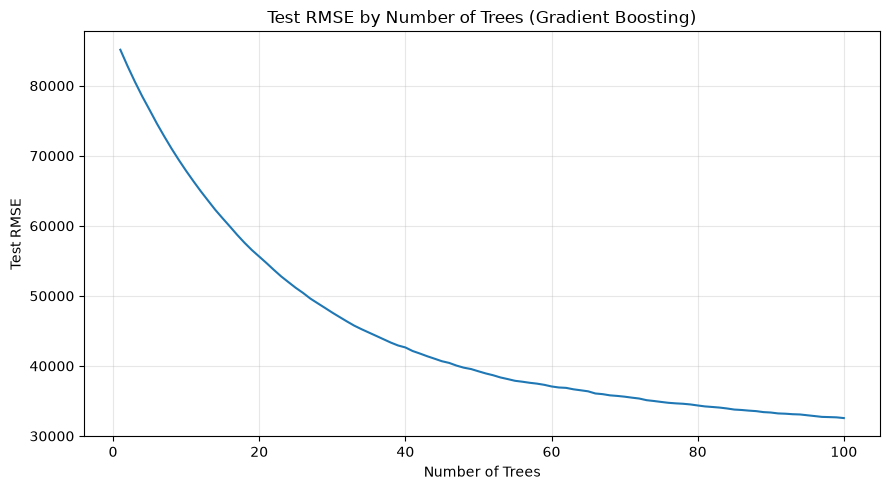

In [11]:
# TODO
# GradientBoostingRegressor를 학습하고
# staged_predict()를 이용해 단계별 Test RMSE를 확인하세요.

gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)
gb.fit(X_train, y_train)

staged_rmse = [
    mean_squared_error(y_test, pred) ** 0.5
    for pred in gb.staged_predict(X_test)
]

staged_result = pd.DataFrame({
    "n_trees": range(1, len(staged_rmse) + 1),
    "test_rmse": [round(r, 1) for r in staged_rmse]
})

print("[단계별 Test RMSE] 총", len(staged_rmse), "단계")
print(staged_result.iloc[[0, 9, 19, 49, 99]].to_string(index=False))

best_idx = staged_rmse.index(min(staged_rmse))
print(f"\n최소 RMSE : {min(staged_rmse):,.1f}  (나무 {best_idx + 1}개)")
print(f"1개 -> 100개 : {staged_rmse[0]:,.1f} -> {staged_rmse[-1]:,.1f} "
      f"({staged_rmse[0] / staged_rmse[-1]:.2f}배 감소)")

plt.figure(figsize=(9, 5))
plt.plot(staged_result["n_trees"], staged_result["test_rmse"])
plt.xlabel("Number of Trees")
plt.ylabel("Test RMSE")
plt.title("Test RMSE by Number of Trees (Gradient Boosting)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


    n_estimators=100 : 최대 100개의 순차적으로 보정을 하는 나무를 추가한다. 
    learning_rate=0.05, : 새 나무의 보정값을 0.05배하여 현재 예측에 더하겠다.
    max_depth=2, : 개별 나무의 깊이를 최대 2개로 제한한다.

    train에서 남은 오차를 다음 나무가 학습한다.
    잔차(실제값-예측값)을 지속적으로 줄여나가는 모델

    RMSE : 예측 오차를 제곱하여 평균을 낸 뒤 제곱근을 더한다. -> 작을수록 좋은 값
    완벽한 예측은 0에 수렴한다.
    오차가 제곱근이 되어 더 크게 반영되기 때문에 큰 오차를 탐지해낼 수 있다.

    판매가격이 달러라면 RMSE도 달러로 해석할 수 있다.
    RMSE가 32,847이라는 것은 제곱 평균 제곱근으로 요약한 오차의 크기가 32,845달러라는 의미

    나무가 많아질수록 test의 오차는 무조건 내려가는가?
    -> 아니오. 학습은 train의 손실을 줄이는 방향으로 진행
    test의 정답으로 보정 나무를 학습하지는 않음
    train의 나무를 계속 추가하면 train의 노이즈까지 학습하여 성능결과가 좋지 않을 수 있음
    
    staged_predict와 early_stopping
    -> 100단계까지 학습한 뒤 test 예측을 관찰하는 것, 중간에 가장 좋은 학습단계가 있어도(손실이 적은)
    100번을 채울 때까지 멈추지 않음
    -> early stopping은 n번만큼 학습했을 때 손실이 더이상 줄어들지 않는 지점을 찾아서 모델을 종료


### Q2. 부스팅에서 나무를 순차적으로 추가하는 이유는 무엇인가요?

**답변:**  
앞선 모델이 남긴 오차를 다음 모델이 학습하여 아직 설명이 충분히 되지 않은 패턴을 계속 보완하려고 함

---

# 필수 2. XGBoost와 LightGBM 비교

## 문제 1. 두 모델을 같은 조건에서 학습하세요.

### 요구사항

다음 공통 설정을 사용합니다.

- `n_estimators=200`
- `learning_rate=0.05`
- `max_depth=3`
- `random_state=42`

다음 두 모델을 학습합니다.

- `XGBRegressor`
- `LGBMRegressor`

각 모델에 대해 다음을 확인합니다.

1. 학습 시간
2. Test RMSE

### 확인 포인트

- XGBoost와 LightGBM을 같은 데이터와 같은 주요 하이퍼파라미터 조건에서 비교했는가?
- LightGBM이 빠른 학습을 강점으로 갖는다는 교안 내용과 연결할 수 있는가?

In [12]:
# TODO
# XGBoost와 LightGBM의 학습 시간과 Test RMSE를 비교하세요.
params = dict(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)

models = {
    "XGBoost": XGBRegressor(**params),
    "LightGBM": LGBMRegressor(**params, verbose=-1),
}

rows = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start

    pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5

    rows.append({"model": name,
                 "fit_time_sec": round(fit_time, 4),
                 "test_rmse": round(rmse, 1)})

compare_result = pd.DataFrame(rows)
print(compare_result.to_string(index=False))

xgb_t, lgb_t = compare_result["fit_time_sec"]
xgb_r, lgb_r = compare_result["test_rmse"]
print(f"\n학습 시간 : LightGBM이 XGBoost의 {lgb_t / xgb_t:.2f}배")
print(f"Test RMSE : 차이 {abs(xgb_r - lgb_r):,.1f} "
      f"(XGBoost 대비 {(lgb_r - xgb_r) / xgb_r * 100:+.2f}%)")


   model  fit_time_sec  test_rmse
 XGBoost        0.2171    28405.3
LightGBM        0.0366    31813.1

학습 시간 : LightGBM이 XGBoost의 0.17배
Test RMSE : 차이 3,407.8 (XGBoost 대비 +12.00%)


Depth-wise : 뿌리에 가까운 깊이의 노드를 우선 확장 (xgboost 원리) -> 최대한 균등하게 분할하겠다.  
-> 같은 깊이의 노드를 균등하게 확장하려고 함  

leaf-wise : 현재 잎들 중 손실을 가장 많이 줄일 분할을 우선 확장 (lightgbm 원리) -> 손실이 많았던 애들 집중공략 하겠다.  
-> 손실 감소가 많았던 친구부터 확장하려고 함

XGBoost의 기본적인 Depth-wise 성장을 따르고 LightBGM은 leaf-wise를 따른다.  
로지스틱회귀는 단순하면 단순할수록 더 잘나옴  

현재 지표로만 대표적인 모델을 설정하는 것은 무리지만 다른 성능평가지표도 함께 체크해야함  
현재 지표로만 대표적인 모델을 설정해본다면 RMSE(오차 제곱근)과 시간 효율성에 좋은 XGBoost를 선택한다.  


### Q3. XGBoost와 LightGBM의 기본 트리 성장 방식 차이는 무엇인가요?

**답변:**  
XGBoost의 기본적인 Depth-wise 성장을 따르고 LightBGM은 leaf-wise를 따른다.

### Q4. CatBoost의 구조적 특징과 강점은 무엇인가요?

**답변:**  
Symmetric Tree 구조 사용, 같은 깊이의 노드에 같은 분할조건을 적용  
범주형 처리에 가장 강한 강점이 있음

## 문제 2. learning_rate와 n_estimators의 관계를 확인하세요.

### 요구사항

다음 조합을 비교합니다.

```python
settings = [
    {"learning_rate": 0.1, "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300}
]
```

각 조합에 대해 `GradientBoostingRegressor(max_depth=2, random_state=42)`를 학습하고 다음을 확인합니다.

1. Test RMSE
2. 학습 시간

### 확인 포인트

- learning_rate가 작을수록 더 많은 나무가 필요할 수 있음을 확인했는가?
- 성능뿐 아니라 학습 시간도 함께 확인했는가?

In [14]:
# TODO
# learning_rate / n_estimators 조합별 Test RMSE와 학습 시간을 비교하세요.

settings = [
    {"learning_rate": 0.1,  "n_estimators": 50},
    {"learning_rate": 0.05, "n_estimators": 100},
    {"learning_rate": 0.01, "n_estimators": 300}
]

rows = []
for setting in settings:
    model = GradientBoostingRegressor(**setting, max_depth=2, random_state=42)

    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start

    pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5

    rows.append({
        "learning_rate": setting["learning_rate"],
        "n_estimators": setting["n_estimators"],
        "lr_x_n": round(setting["learning_rate"] * setting["n_estimators"], 2),
        "test_rmse": round(rmse, 1),
        "fit_time_sec": round(fit_time, 4)
    })

lr_result = pd.DataFrame(rows)
print(lr_result.to_string(index=False))

best = lr_result.loc[lr_result["test_rmse"].idxmin()]
print(f"\n최소 RMSE : {best['test_rmse']:,.1f} "
      f"(learning_rate={best['learning_rate']}, n_estimators={int(best['n_estimators'])})")
print(f"RMSE 최대-최소 차이 : "
      f"{lr_result['test_rmse'].max() - lr_result['test_rmse'].min():,.1f}")

 learning_rate  n_estimators  lr_x_n  test_rmse  fit_time_sec
          0.10            50     5.0    31791.3        0.0497
          0.05           100     5.0    32559.2        0.0837
          0.01           300     3.0    37166.0        0.2466

최소 RMSE : 31,791.3 (learning_rate=0.1, n_estimators=50)
RMSE 최대-최소 차이 : 5,374.7


learning_rate의 0.05의 의미  
새 나무가 출력한 보정값을 0.05배하여 더한다는 뜻  

작은 학습률에서 더 많은 나무가 필요한 경우가 있는지?  
learning_rate가 작으면 유용한 패턴을 누적하여 학습하는 데에 오랜 시간과 단계가 필요할 수 있다.  
주어진 나무의 수가 적다면 보정이 덜 된 상태로 학습이 끝날 가능성이 있다.  


### Q5. learning_rate를 작게 만들면 왜 n_estimators를 함께 늘려야 할 수 있나요?

**답변:**  
각 나무가 최종 예측에 반영되는 비율이 작기 때문에 같은 정도의 오차 보완을 위해 더 많은 단계가 필요할 수 있다.

---

# 과제 1. Early Stopping과 부스팅 모델 선택

## 배경

교안에서는 `n_estimators`를 충분히 크게 설정하고, 검증 성능이 더 이상 좋아지지 않으면 학습을 멈추는 **Early Stopping**을 소개했습니다.

이번 과제에서는 XGBoost에서 이 흐름을 적용합니다.

> 과제는 필수 실습에서 사용한 모델과 하이퍼파라미터를 그대로 활용하는 수준입니다.

## 요구사항

1. Train 데이터를 다시 Train / Validation으로 나눕니다.
2. `XGBRegressor`를 사용합니다.
3. `n_estimators=1000`
4. `learning_rate=0.05`
5. `max_depth=3`
6. `early_stopping_rounds=20`
7. Train 데이터로 학습하고 Validation 데이터를 `eval_set`으로 전달합니다.
8. Test 데이터의 RMSE를 계산합니다.
9. 실제로 사용된 나무 수를 확인합니다.
10. `n_estimators=1000`을 모두 사용하지 않고 중간에 멈췄다면 그 이유를 설명합니다.

11. Q7에서 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산, 과적합에 미치는 영향을 비교합니다. 새로운 모델 학습 코드는 요구하지 않습니다.

### 확인 포인트

- Early Stopping이 Validation 성능을 기준으로 동작한다는 점을 이해했는가?
- 불필요하게 많은 나무를 쌓는 것을 막는 목적을 설명할 수 있는가?
- 과적합 방지와 학습 시간 절약이라는 두 가지 의미를 설명할 수 있는가?
- 배깅의 부트스트랩·예측 결합, 랜덤포레스트의 특성 무작위 선택, 부스팅의 순차적 오류 보완을 설명할 수 있는가?
- 각 방식이 편향·분산에 미치는 일반적인 영향과 과적합 가능성을 구분할 수 있는가?


In [13]:
# TODO
# XGBoost에 Early Stopping을 적용하세요.

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)
print("Train 크기:", X_tr.shape)
print("Validation 크기:", X_val.shape)
print("Test 크기:", X_test.shape)

xgb_es = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric="rmse"
)
xgb_es.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

pred = xgb_es.predict(X_test)
test_rmse = mean_squared_error(y_test, pred) ** 0.5

val_rmse_history = xgb_es.evals_result()["validation_0"]["rmse"]

print(f"\n설정한 n_estimators        : 1000")
print(f"실제 사용된 나무 수        : {xgb_es.best_iteration + 1}")
print(f"학습이 중단된 시점         : {len(val_rmse_history)}번째 나무")
print(f"최적 시점 Validation RMSE  : {val_rmse_history[xgb_es.best_iteration]:,.1f}")
print(f"마지막 시점 Validation RMSE: {val_rmse_history[-1]:,.1f}")
print(f"Test RMSE                  : {test_rmse:,.1f}")

print("\n[Validation RMSE 추이 일부]")
check = [0, 9, 19, xgb_es.best_iteration, len(val_rmse_history) - 1]
for i in sorted(set(check)):
    mark = "  <- 최적" if i == xgb_es.best_iteration else ""
    print(f"  {i + 1:4d}번째 나무 : {val_rmse_history[i]:10,.1f}{mark}")

Train 크기: (934, 12)
Validation 크기: (234, 12)
Test 크기: (292, 12)

설정한 n_estimators        : 1000
실제 사용된 나무 수        : 108
학습이 중단된 시점         : 128번째 나무
최적 시점 Validation RMSE  : 27,900.4
마지막 시점 Validation RMSE: 28,057.9
Test RMSE                  : 30,332.9

[Validation RMSE 추이 일부]
     1번째 나무 :   77,630.3
    10번째 나무 :   58,740.2
    20번째 나무 :   45,759.3
   108번째 나무 :   27,900.4  <- 최적
   128번째 나무 :   28,057.9


### Q6. Early Stopping은 어떤 상황에서 학습을 멈추나요?

**답변:**  
Validation 데이터의 최적 성능이 갱신되지 않은 상태가 early_stopping_rounds에 지정한 횟수만큼 연속으로 이어지면 학습을 중단함  
-> early_stopping_rounds가 20이므로 최적 시점 이후 20개의 나무를 추가해도 Validation 성능이 갱신되지 않으면 멈춤.  

(이건 내가 안헷갈리려고 적어둠)
- 판단 기준 : Validation  
-> Train 성능은 나무를 추가할수록 계속 좋아질 수 있어 중단 기준이 되지 못하므로, 학습에 쓰지 않은 Validation 데이터로 성능이 갱신되지 않는 시점을 판단함.  

- Validation 성능이 개선되지 않는 구간의 나무를 계속 쌓으면 Train에만 맞춰지는 방향으로 갈 수 있으므로 과적합을 줄이는데 도움이 될 수 있음  
- n_estimators로 설정한 1000개의 나무를 모두 학습하지 않고 중단하므로 학습 시간을 절약함.  

(튜터님 답변)  
Early Stopping을 사용하는 이유  
학습을 멈출 수 있는 장치인 Early Stopping이 없다면 최적의 RMSE를 보여도 모델은 멈추지 않고 학습할 수 있다.  
Early Stopping은 가장 좋은 단계의 나무 수를 통해 손실이 갱신이 없으면 학습을 강제로 종료하여 최적의 성능과 시간적 효율을 높이기 위함.  

### Q7. 배깅·랜덤포레스트·부스팅의 작동 원리와 편향·분산에 미치는 영향을 비교하세요.

다음 항목을 포함하여 각 방법을 설명하세요.

1. **배깅:** 부트스트랩 표본을 만드는 방법과 여러 모델의 예측을 결합하는 방법, 분산 감소의 이유
2. **랜덤포레스트:** 배깅에 더해 각 노드의 분할 후보 특성을 무작위로 선택하는 이유와 트리 간 상관·분산에 미치는 영향
3. **부스팅:** 이전 모델의 오류를 순차적으로 보완하는 원리와 편향 감소의 관계, 과적합 가능성 및 이를 줄이는 방법

> 편향·분산에 대한 효과는 일반적인 경향입니다. 한 방법이 편향 또는 분산만 바꾸거나 과적합을 항상 막는다고 단정하지 마세요.

**답변:**

[배깅]  
- `부트스트랩 표본을 만드는 방법` : 원본 Train 데이터에서 중복을 허용해 무작위로 원본과 같은 개수만큼 뽑는 과정을 반복해 표본을 여러 개 만들고, 각 표본에 독립적으로 모델을 학습시킴  
- `여러 모델의 예측을 결합하는 방법` : 회귀에서는 평균, 분류에서는 다수결로 결합함.  
- `분산 감소의 이유` : 모델마다 학습에 쓰인 행 구성이 달라 예측이 서로 다른 방향으로 흔들리는데, 이를 평균하면 개별 모델의 흔들림이 서로 상쇄되어 분산이 줄어드는 경향이 있음.  

[랜덤포레스트]   
- `이유`: Bagging만 쓰면 나무마다 데이터는 조금씩 달라도, 영향력이 가장 큰 특성으로 비슷하게 갈라지기 쉬워 나무들이 서로 닮게 되기 때문에  
-> 노드마다 일부 특성만 후보로 주면, 가장 강한 특성이 빠지는 노드에서는 다른 특성으로 갈라지게 되어 나무들이 다양해짐  
- `트리 간 상관`: 나무들이 서로 다른 기준으로 갈라지므로 예측이 덜 비슷해져 상관이 낮아지는 경향이 있음  
- `분산`: 나무들이 서로 다른 방향으로 흔들릴수록 평균할 때 더 잘 상쇄되어 전체 예측의 분산이 줄어드는 경향이 있음  
-> 개별 나무는 매번 가장 좋은 특성을 쓰지 못할 수 있어, 모든 특성을 쓰는 나무보다 성능이 떨어지고 편향이 커지는 경향이 생길 수 있음


[부스팅]  
- `원리`: 앞 나무가 남긴 잔차를 다음 나무가 target으로 삼아 학습하고, 그 예측에 learning_rate를 곱해 누적하여 오류를 보완해 가는 과정을 반복함  
-> 나무들이 서로 독립인 Bagging과 달리, Boosting은 앞의 실수를 고쳐나감  

- `편향 감소`: 앞 나무가 아직 설명하지 못한 부분(잔차)를 다음 나무가 단계적으로 채워 나가므로 편향이 줄어드는 경향이 있음.  
-> 얕은 나무 하나로는 못잡는 패턴도, 단순한 나무를 여러 단계 쌓아 맞출 수 있게 됨  
- `과적합 가능성`: 단계를 계속 쌓으면 Train 데이터의 세부까지 맞추는 방향으로 갈 수 있어 Bagging보다 과적합 가능성이 상대적으로 높음.  
-> Train 성능은 좋아도 Validation 성능은 떨어질 수 있음  

- `과적합 줄이는 방법`
    - learning_rate ↓ : 보폭을 줄여 조금씩 다가가기    
    -> 큰 보폭으로 가면 목표를 지나칠 수 있어, 작은 보폭으로 조금씩 다가가게 하기
    - max_depth ↓ : 얕은 나무(개별 모델)로 바꿔 단순하게 유지  
    -> 문제를 세밀하게 외우지 않고, 큰 흐름만 익히게 하는 것
    - Early Stopping : Validation 성능을 기준으로 나무 추가를 중단하기  
    -> 모의고사 점수가 더 안오르면, 같은 문제집만 반복해서 외우기 전에 공부를 멈추기  

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

* 1. 부스팅은 여러 모델을 병렬로 학습하나요, 순차적으로 학습하나요?  
-> 순차학습  

2. AdaBoost는 이전 모델이 틀린 샘플을 어떻게 처리하나요?  
-> 이전 모델이 틀린 샘플의 가중치를 높인다.  

* 3. Gradient Boosting은 다음 모델이 무엇을 학습하나요?  
-> 이전 모델이 남긴 잔차를 다음 모델이 학습한다.  

4. XGBoost와 LightGBM의 기본 트리 성장 방식은 어떻게 다른가요?  
-> XGBoost : level-wise  
-> lightGBM : leaf-wise   

* 5. `learning_rate`와 `n_estimators`는 어떤 관계가 있나요?  
-> learning rate가 작을수록 일반적으로 더 많은 나무가 필요할 수 있다.  

* 6. Early Stopping을 사용하는 이유는 무엇인가요?  
-> validation 성능이 더이상 좋아지지 않을 때(학습 손실이 더이상 줄어들지 않을때)  
-> 학습을 멈춰서 과적합과 불필요한 학습을 줄인다.  

7. 부스팅은 편향과 분산 중 어떤 문제를 줄이는 데 특히 초점을 두나요?  
-> 단계적으로 이전 오차를 보완하면서 편향을 줄이는데 초점을 둔다.